# Previsión de tesorería a 60 días

Este notebook realiza el análisis completo a partir de los datos creados por
**generador_datos.py**, que es la única fuente de generación del escenario
sintético.

El objetivo no es predecir directamente el saldo bancario. Primero se estiman
los cobros y pagos operativos inciertos, después se incorporan los pagos
programados y finalmente se reconstruye el saldo.

**Recorrido**

1. Generación de datos mediante **generador_datos.py**.
2. Comprobaciones y análisis exploratorio.
3. Preparación de variables de calendario.
4. Validación temporal.
5. Comparación con un baseline.
6. Evaluación final.
7. Escenarios de liquidez.

Todos los importes, empresas y reglas de este ejercicio son ficticios.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor

pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
plt.style.use("seaborn-v0_8-whitegrid")

HORIZON = 60

Path("data").mkdir(exist_ok=True)
Path("reports/figures").mkdir(parents=True, exist_ok=True)

## 1. Origen de los datos

El archivo **generador_datos.py** contiene todas las reglas del escenario y es
la única fuente utilizada para crear el dataset. El notebook no vuelve a
definir esas reglas.

| Componente | Regla simulada en el generador |
|---|---|
| Cobros recurrentes | Se concentran entre los días 1 y 5 de diez meses del año |
| Actividad estival | Cobros diarios distintos entre semana y fin de semana |
| Pagos operativos | Gasto diario con mayor nivel durante julio y agosto |
| Nóminas | 350.000 € el día 28 |
| Deuda o leasing | 1.200.000 € el día 5 |
| Impuestos | 400.000 € en fechas trimestrales |
| Pago extraordinario | 1.000.000 € el 30 de junio |

Se importa la función de generación, se ejecuta y se guarda su resultado. Si
alguna regla cambia, debe modificarse en **generador_datos.py**, no en este
notebook.

In [2]:
from generador_datos import (
    END_DATE,
    OPENING_BALANCE,
    RANDOM_STATE,
    START_DATE,
    generate_cash_flow_data,
    scheduled_payments,
)

data = generate_cash_flow_data()
data["Fecha"] = pd.to_datetime(data["Fecha"])
data.to_csv("data/tesoreria_sintetica.csv", index=False)

display(data.head(10))

reconstructed_flow = (
    data["Cobros"]
    - data["Pagos_Operativos"]
    - data["Pagos_Programados"]
)

print(f"Periodo: {START_DATE} — {END_DATE}")
print(f"Número de días: {len(data):,}")
print(
    "Identidad financiera correcta:",
    np.allclose(reconstructed_flow, data["Flujo_Caja"], atol=0.02),
)
print("Valores ausentes:", int(data.isna().sum().sum()))
print("Duplicados de fecha:", int(data["Fecha"].duplicated().sum()))

Periodo: 2021-01-01 — 2026-02-28
Número de días: 1,885
Identidad financiera correcta: True
Valores ausentes: 0
Duplicados de fecha: 0


,Fecha,Cobros,Pagos_Operativos,Pagos_Programados,Flujo_Caja,Saldo_Bancario
0,2021-01-01,"465,235.85","15,400.10",0.00,"449,835.75","3,649,835.75"
1,2021-01-02,"398,000.79","13,404.66",0.00,"384,596.13","4,034,431.88"
2,2021-01-03,"487,522.56","15,299.45",0.00,"472,223.11","4,506,654.99"
3,2021-01-04,"497,028.24","12,658.20",0.00,"484,370.04","4,991,025.03"
4,2021-01-05,"352,448.24","15,814.29","1,200,000.00","-863,366.05","4,127,658.98"
5,2021-01-06,"2,348.91","16,536.77",0.00,"-14,187.86","4,113,471.13"
6,2021-01-07,"3,063.92","13,825.23",0.00,"-10,761.31","4,102,709.82"
7,2021-01-08,"2,841.88","13,294.62",0.00,"-10,452.74","4,092,257.08"
8,2021-01-09,"2,991.60","11,765.97",0.00,"-8,774.37","4,083,482.71"
9,2021-01-10,"2,573.48","14,600.38",0.00,"-12,026.90","4,071,455.81"


## 2. Análisis exploratorio

El análisis comienza por revisar la escala y la distribución de cada componente. El saldo es acumulativo, por lo que su magnitud no debe compararse directamente con la de los flujos diarios.

In [3]:
summary = data[
    ["Cobros", "Pagos_Operativos", "Pagos_Programados", "Flujo_Caja", "Saldo_Bancario"]
].describe().T
summary[["mean", "std", "min", "50%", "max"]].round(2)

,mean,std,min,50%,max
Cobros,"78,454.29","157,401.34","1,571.74","3,372.74","628,112.23"
Pagos_Operativos,"17,088.71","4,120.74","10,428.55","15,795.76","30,587.85"
Pagos_Programados,"58,090.19","229,087.23",0.00,0.00,"1,200,000.00"
Flujo_Caja,"3,275.40","231,912.63","-1,173,002.80","-11,711.81","561,899.76"
Saldo_Bancario,"5,992,557.83","1,831,243.77","1,840,091.47","5,787,739.06","10,795,657.35"


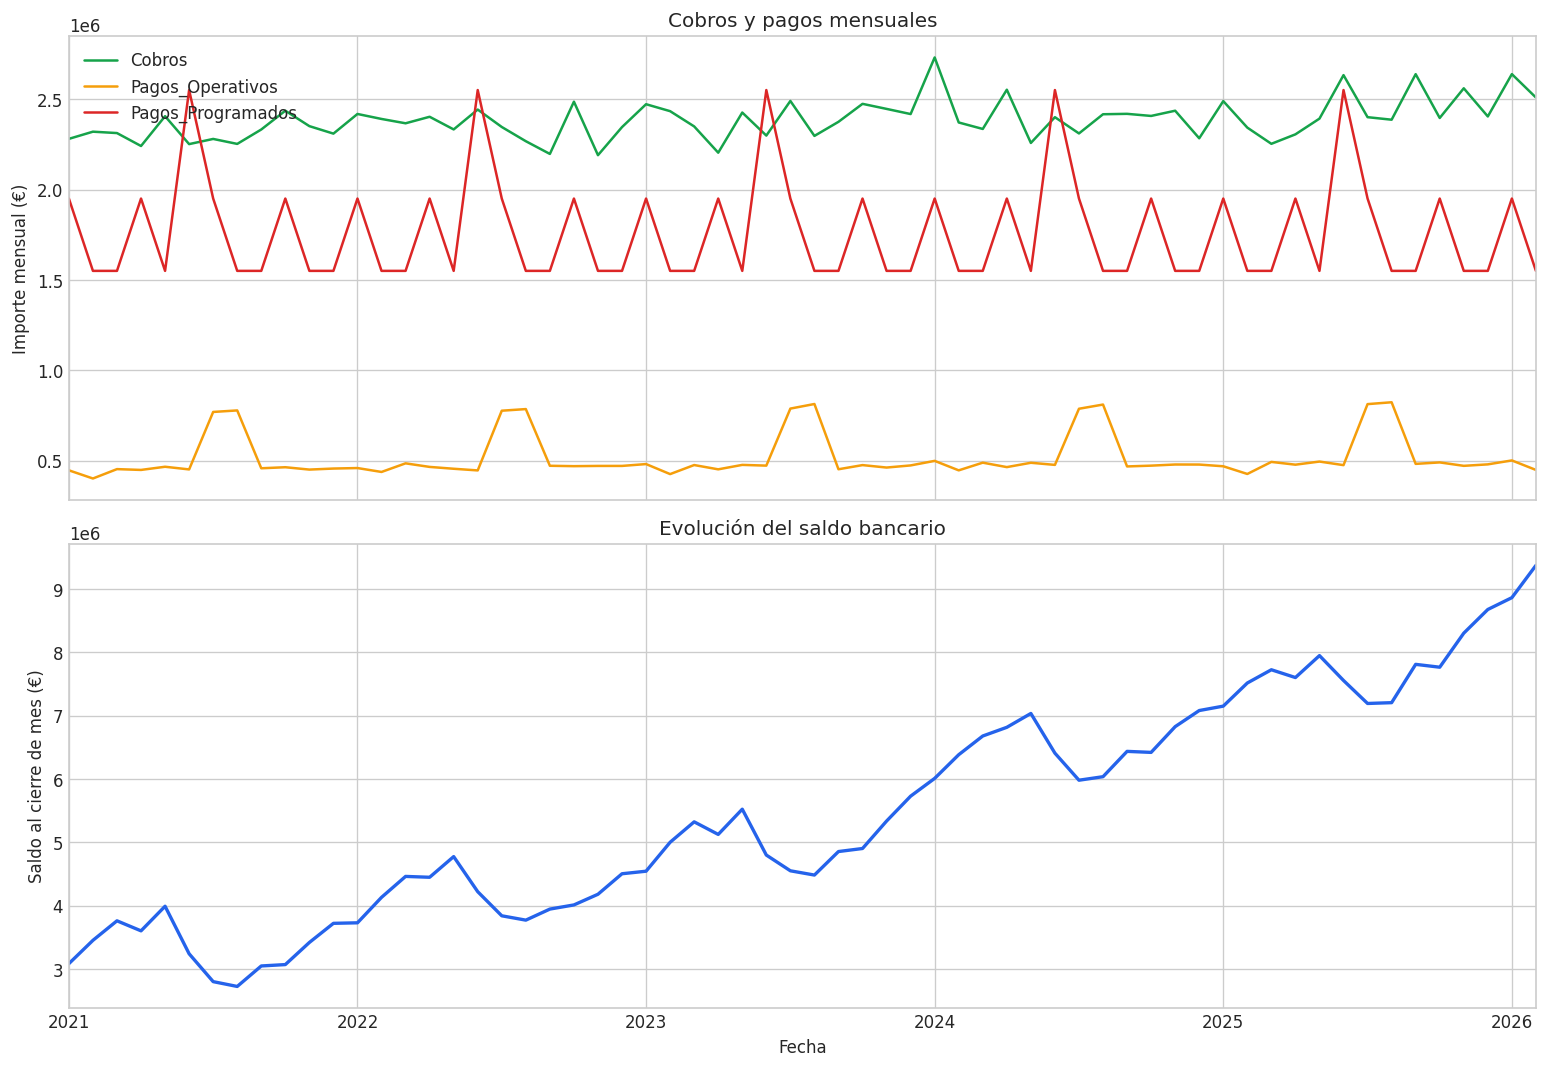

In [4]:
monthly = (
    data.set_index("Fecha")
    .resample("MS")
    .agg(
        {
            "Cobros": "sum",
            "Pagos_Operativos": "sum",
            "Pagos_Programados": "sum",
            "Flujo_Caja": "sum",
            "Saldo_Bancario": "last",
        }
    )
)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

monthly[["Cobros", "Pagos_Operativos", "Pagos_Programados"]].plot(
    ax=axes[0],
    color=["#16a34a", "#f59e0b", "#dc2626"],
)
axes[0].set_title("Cobros y pagos mensuales")
axes[0].set_ylabel("Importe mensual (€)")

monthly["Saldo_Bancario"].plot(ax=axes[1], color="#2563eb", linewidth=2)
axes[1].set_title("Evolución del saldo bancario")
axes[1].set_ylabel("Saldo al cierre de mes (€)")
axes[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

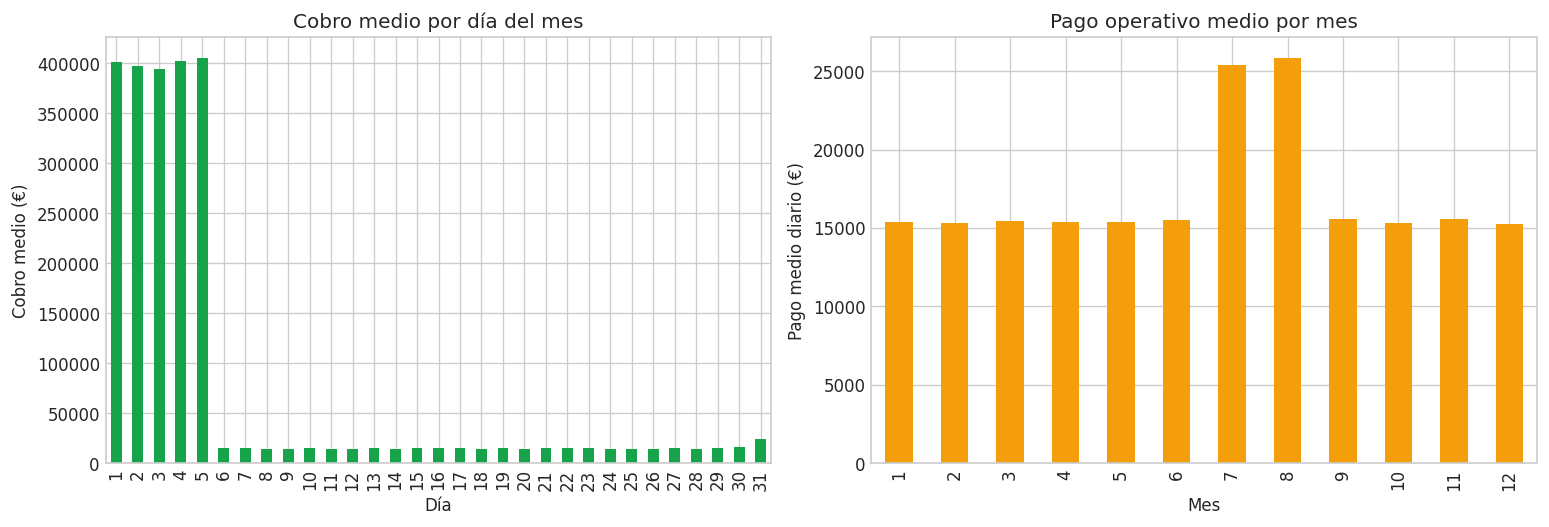

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

data.groupby(data["Fecha"].dt.day)["Cobros"].mean().plot(
    kind="bar", ax=axes[0], color="#16a34a"
)
axes[0].set_title("Cobro medio por día del mes")
axes[0].set_xlabel("Día")
axes[0].set_ylabel("Cobro medio (€)")

data.groupby(data["Fecha"].dt.month)["Pagos_Operativos"].mean().plot(
    kind="bar", ax=axes[1], color="#f59e0b"
)
axes[1].set_title("Pago operativo medio por mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Pago medio diario (€)")

plt.tight_layout()
plt.show()

### Lectura del EDA

Los cobros se concentran claramente al principio del mes. Los pagos operativos aumentan en verano y los pagos programados provocan caídas puntuales del saldo.

Predecir directamente el saldo sería problemático: al ser una suma acumulada, presenta una tendencia suave y mucha autocorrelación. Un modelo podría parecer preciso limitándose a prolongar esa tendencia. Por eso se modelizan por separado cobros y pagos operativos.

In [6]:
correlation = data[["Flujo_Caja", "Saldo_Bancario"]].corr()
display(correlation)

reconstructed_balance = OPENING_BALANCE + data["Flujo_Caja"].cumsum()
print(
    "Saldo reconstruido correctamente:",
    np.allclose(reconstructed_balance, data["Saldo_Bancario"], atol=0.02),
)

Saldo reconstruido correctamente: True


,Flujo_Caja,Saldo_Bancario
Flujo_Caja,1.00,0.07
Saldo_Bancario,0.07,1.00


## 3. Variables disponibles en el momento de predecir

Solo se utilizan variables que pueden conocerse para una fecha futura: tendencia temporal, ciclos semanales y anuales, día del mes, ventana de cobro, verano, fin de semana y cierre de mes.

No se emplean valores futuros de cobros, pagos o saldo.

In [7]:
def calendar_features(feature_dates, origin):
    index = pd.DatetimeIndex(pd.to_datetime(feature_dates))
    day_of_year = index.dayofyear.to_numpy()
    day_of_week = index.dayofweek.to_numpy()
    day_of_month = index.day.to_numpy()
    month_number = index.month.to_numpy()

    return pd.DataFrame(
        {
            "trend_days": (index - origin).days,
            "dow_sin": np.sin(2 * np.pi * day_of_week / 7),
            "dow_cos": np.cos(2 * np.pi * day_of_week / 7),
            "year_sin": np.sin(2 * np.pi * day_of_year / 365.25),
            "year_cos": np.cos(2 * np.pi * day_of_year / 365.25),
            "month_sin": np.sin(2 * np.pi * month_number / 12),
            "month_cos": np.cos(2 * np.pi * month_number / 12),
            "day_sin": np.sin(2 * np.pi * day_of_month / 31),
            "day_cos": np.cos(2 * np.pi * day_of_month / 31),
            "collection_window": (day_of_month <= 5).astype(int),
            "summer": np.isin(month_number, [7, 8]).astype(int),
            "weekend": (day_of_week >= 5).astype(int),
            "month_end": index.is_month_end.astype(int),
        },
        index=index,
    )

features_example = calendar_features(data["Fecha"].head(10), data["Fecha"].min())
features_example

,trend_days,dow_sin,dow_cos,year_sin,year_cos,month_sin,month_cos,day_sin,day_cos,collection_window,summer,weekend,month_end
Fecha,,,,,,,,,,,,,
2021-01-01,0,-0.43,-0.90,0.02,1.00,0.50,0.87,0.20,0.98,1,0,0,0
2021-01-02,1,-0.97,-0.22,0.03,1.00,0.50,0.87,0.39,0.92,1,0,1,0
2021-01-03,2,-0.78,0.62,0.05,1.00,0.50,0.87,0.57,0.82,1,0,1,0
2021-01-04,3,0.00,1.00,0.07,1.00,0.50,0.87,0.72,0.69,1,0,0,0
2021-01-05,4,0.78,0.62,0.09,1.00,0.50,0.87,0.85,0.53,1,0,0,0
2021-01-06,5,0.97,-0.22,0.10,0.99,0.50,0.87,0.94,0.35,0,0,0,0
2021-01-07,6,0.43,-0.90,0.12,0.99,0.50,0.87,0.99,0.15,0,0,0,0
2021-01-08,7,-0.43,-0.90,0.14,0.99,0.50,0.87,1.00,-0.05,0,0,0,0
2021-01-09,8,-0.97,-0.22,0.15,0.99,0.50,0.87,0.97,-0.25,0,0,1,0


## 4. Métodos comparados

### Baseline estacional

Para cada fecha futura utiliza los cobros y pagos operativos observados el mismo día del año anterior. Los pagos programados se calculan con el calendario actual.

### Gradient boosting

Se entrenan dos modelos independientes:

- uno para cobros;
- otro para pagos operativos.

Después se añaden los pagos programados y se calcula:

\[
Flujo\ de\ caja = Cobros - Pagos\ operativos - Pagos\ programados
\]

El saldo previsto es la suma acumulada del flujo previsto desde el último saldo conocido.

In [8]:
def seasonal_naive_forecast(train, forecast_dates):
    history = train.copy().set_index("Fecha")
    rows = []

    for forecast_date in pd.DatetimeIndex(forecast_dates):
        previous_date = forecast_date - pd.DateOffset(years=1)
        if previous_date not in history.index:
            previous_date -= pd.Timedelta(days=1)

        if previous_date in history.index:
            source = history.loc[previous_date]
        else:
            source = history.iloc[-365:][["Cobros", "Pagos_Operativos"]].median()

        collections_prediction = float(source["Cobros"])
        operating_prediction = float(source["Pagos_Operativos"])
        programmed = float(
            scheduled_payments(pd.DatetimeIndex([forecast_date]))[0]
        )

        rows.append(
            {
                "Fecha": forecast_date,
                "Cobros_Previstos": collections_prediction,
                "Pagos_Operativos_Previstos": operating_prediction,
                "Pagos_Programados": programmed,
                "Flujo_Caja_Previsto": (
                    collections_prediction - operating_prediction - programmed
                ),
            }
        )
    return pd.DataFrame(rows)


def gradient_boosting_forecast(train, forecast_dates):
    origin = train["Fecha"].min()
    train_features = calendar_features(train["Fecha"], origin)
    future_features = calendar_features(forecast_dates, origin)
    predictions = {}

    for target in ["Cobros", "Pagos_Operativos"]:
        model = HistGradientBoostingRegressor(
            learning_rate=0.06,
            max_iter=250,
            max_leaf_nodes=20,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        )
        model.fit(train_features, train[target])
        predictions[target] = np.maximum(model.predict(future_features), 0)

    programmed = scheduled_payments(forecast_dates)
    return pd.DataFrame(
        {
            "Fecha": pd.DatetimeIndex(forecast_dates),
            "Cobros_Previstos": predictions["Cobros"],
            "Pagos_Operativos_Previstos": predictions["Pagos_Operativos"],
            "Pagos_Programados": programmed,
            "Flujo_Caja_Previsto": (
                predictions["Cobros"]
                - predictions["Pagos_Operativos"]
                - programmed
            ),
        }
    )


def add_balance(forecast, opening_balance):
    result = forecast.copy()
    result["Saldo_Previsto"] = (
        opening_balance + result["Flujo_Caja_Previsto"].cumsum()
    )
    return result

## 5. Validación temporal y métricas

No se realiza una partición aleatoria porque mezclaría pasado y futuro. Se utilizan tres ventanas cronológicas de 60 días para seleccionar el método.

El periodo comprendido entre el 31 de diciembre de 2025 y el 28 de febrero de 2026 queda reservado como prueba final y no participa en la selección.

Las métricas son:

- **MAE:** error absoluto medio expresado en euros.
- **RMSE:** penaliza con más fuerza los errores grandes.
- **WAPE:** error absoluto acumulado dividido entre el volumen absoluto real.
- **MAE del saldo:** diferencia media entre el saldo real y el reconstruido.

In [9]:
VALIDATION_STARTS = pd.to_datetime(
    ["2025-03-01", "2025-06-01", "2025-09-01"]
)
TEST_START = pd.Timestamp("2025-12-31")
TEST_END = TEST_START + pd.Timedelta(days=HORIZON - 1)

splits = pd.DataFrame(
    {
        "Conjunto": ["Validación 1", "Validación 2", "Validación 3", "Prueba final"],
        "Inicio": [*VALIDATION_STARTS, TEST_START],
    }
)
splits["Fin"] = splits["Inicio"] + pd.Timedelta(days=HORIZON - 1)
splits

,Conjunto,Inicio,Fin
0,Validación 1,2025-03-01,2025-04-29
1,Validación 2,2025-06-01,2025-07-30
2,Validación 3,2025-09-01,2025-10-30
3,Prueba final,2025-12-31,2026-02-28


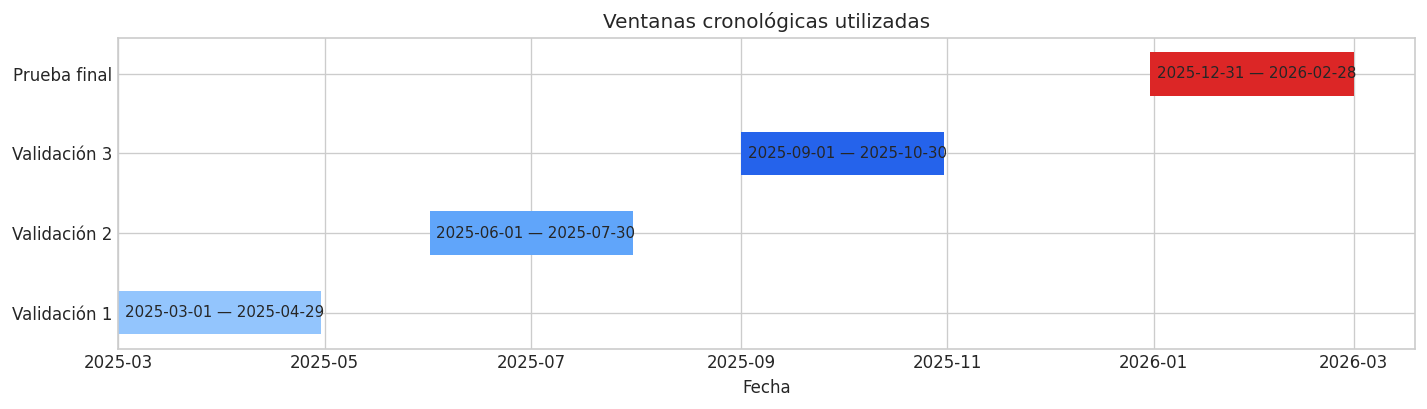

In [10]:
fig, ax = plt.subplots(figsize=(12, 3.5))
colors = ["#93c5fd", "#60a5fa", "#2563eb", "#dc2626"]

for position, row in splits.iterrows():
    ax.barh(
        row["Conjunto"],
        HORIZON,
        left=row["Inicio"],
        height=0.55,
        color=colors[position],
    )
    ax.text(
        row["Inicio"] + pd.Timedelta(days=2),
        position,
        f'{row["Inicio"].date()} — {row["Fin"].date()}',
        va="center",
        fontsize=9,
    )

ax.set_title("Ventanas cronológicas utilizadas")
ax.set_xlabel("Fecha")
plt.tight_layout()
plt.show()

In [11]:
def regression_metrics(actual, predicted):
    errors = np.asarray(actual) - np.asarray(predicted)
    denominator = max(float(np.abs(actual).sum()), 1.0)
    return {
        "mae": float(np.abs(errors).mean()),
        "rmse": float(np.sqrt(np.mean(errors**2))),
        "wape": float(np.abs(errors).sum() / denominator),
    }


def evaluate_forecast(actual, forecast):
    merged = actual.merge(forecast, on="Fecha", validate="one_to_one")
    flow = regression_metrics(
        merged["Flujo_Caja"],
        merged["Flujo_Caja_Previsto"],
    )
    balance = regression_metrics(
        merged["Saldo_Bancario"],
        merged["Saldo_Previsto"],
    )
    return {
        "cash_flow_mae": flow["mae"],
        "cash_flow_rmse": flow["rmse"],
        "cash_flow_wape": flow["wape"],
        "balance_mae": balance["mae"],
        "ending_balance_error": float(
            merged["Saldo_Previsto"].iloc[-1]
            - merged["Saldo_Bancario"].iloc[-1]
        ),
    }


def predict_with_method(method, train, forecast_dates):
    if method == "seasonal_naive":
        forecast = seasonal_naive_forecast(train, forecast_dates)
    elif method == "gradient_boosting":
        forecast = gradient_boosting_forecast(train, forecast_dates)
    else:
        raise ValueError(f"Método desconocido: {method}")

    return add_balance(forecast, float(train["Saldo_Bancario"].iloc[-1]))

### 5.1 Backtesting

En cada ventana, el modelo solo se entrena con observaciones anteriores a la fecha de inicio. Los dos métodos se evalúan sobre exactamente los mismos 60 días.

In [12]:
validation_rows = []

for validation_start in VALIDATION_STARTS:
    validation_end = validation_start + pd.Timedelta(days=HORIZON - 1)
    train = data[data["Fecha"] < validation_start].copy()
    actual = data[data["Fecha"].between(validation_start, validation_end)].copy()

    for method in ["seasonal_naive", "gradient_boosting"]:
        forecast = predict_with_method(
            method,
            train,
            pd.DatetimeIndex(actual["Fecha"]),
        )
        validation_rows.append(
            {
                "Ventana": validation_start.date().isoformat(),
                "Método": method,
                **evaluate_forecast(actual, forecast),
            }
        )

validation_results = pd.DataFrame(validation_rows)
validation_results.round(4)

,Ventana,Método,cash_flow_mae,cash_flow_rmse,cash_flow_wape,balance_mae,ending_balance_error
0,2025-03-01,seasonal_naive,"13,390.57","32,222.48",0.12,"205,587.97","343,105.82"
1,2025-03-01,gradient_boosting,"7,539.55","19,266.61",0.07,"67,185.93","109,736.87"
2,2025-06-01,seasonal_naive,"14,172.92","24,261.27",0.12,"237,342.61","-306,823.27"
3,2025-06-01,gradient_boosting,"9,747.42","22,656.36",0.08,"248,841.66","-280,391.01"
4,2025-09-01,seasonal_naive,"12,389.44","32,697.20",0.11,"189,359.25","-177,203.80"
5,2025-09-01,gradient_boosting,"8,153.74","22,028.15",0.07,"181,063.64","-143,790.54"


Método seleccionado: gradient_boosting


,WAPE_Medio,MAE_Flujo_Medio,MAE_Saldo_Medio
Método,,,
gradient_boosting,0.07,"8,480.24","165,697.08"
seasonal_naive,0.12,"13,317.64","210,763.28"


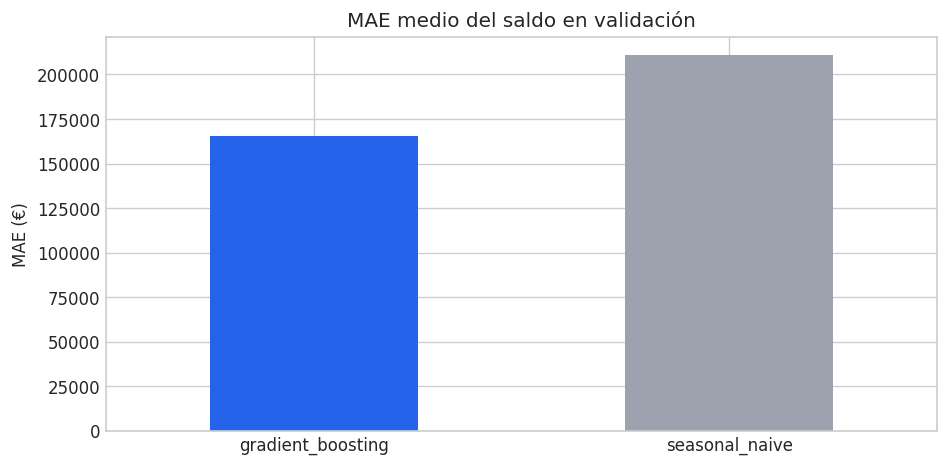

In [13]:
validation_summary = (
    validation_results.groupby("Método")
    .agg(
        WAPE_Medio=("cash_flow_wape", "mean"),
        MAE_Flujo_Medio=("cash_flow_mae", "mean"),
        MAE_Saldo_Medio=("balance_mae", "mean"),
    )
    .sort_values("MAE_Saldo_Medio")
)

selected_method = validation_summary.index[0]
display(validation_summary.round(4))
print("Método seleccionado:", selected_method)

fig, ax = plt.subplots(figsize=(8, 4))
validation_summary["MAE_Saldo_Medio"].sort_values().plot(
    kind="bar",
    ax=ax,
    color=["#2563eb", "#9ca3af"],
)
ax.set_title("MAE medio del saldo en validación")
ax.set_ylabel("MAE (€)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 6. Evaluación final

Una vez elegido el método con las ventanas de validación, se abre el periodo de prueba. Los dos métodos se muestran para facilitar la comparación, pero la decisión ya se tomó sin consultar estos datos.

In [14]:
train_test = data[data["Fecha"] < TEST_START].copy()
actual_test = data[data["Fecha"].between(TEST_START, TEST_END)].copy()

test_forecasts = {}
test_rows = []

for method in ["seasonal_naive", "gradient_boosting"]:
    forecast = predict_with_method(
        method,
        train_test,
        pd.DatetimeIndex(actual_test["Fecha"]),
    )
    test_forecasts[method] = forecast
    test_rows.append(
        {
            "Método": method,
            **evaluate_forecast(actual_test, forecast),
        }
    )

test_results = pd.DataFrame(test_rows).set_index("Método")
display(test_results.round(4))

baseline_mae = test_results.loc["seasonal_naive", "balance_mae"]
model_mae = test_results.loc["gradient_boosting", "balance_mae"]
improvement = 1 - model_mae / baseline_mae

print(f"Reducción del MAE del saldo frente al baseline: {improvement:.1%}")

Reducción del MAE del saldo frente al baseline: 35.0%


,cash_flow_mae,cash_flow_rmse,cash_flow_wape,balance_mae,ending_balance_error
Método,,,,,
seasonal_naive,"13,833.10","32,346.51",0.12,"193,788.30","-259,802.12"
gradient_boosting,"9,422.54","21,741.51",0.08,"125,951.95","-136,959.50"


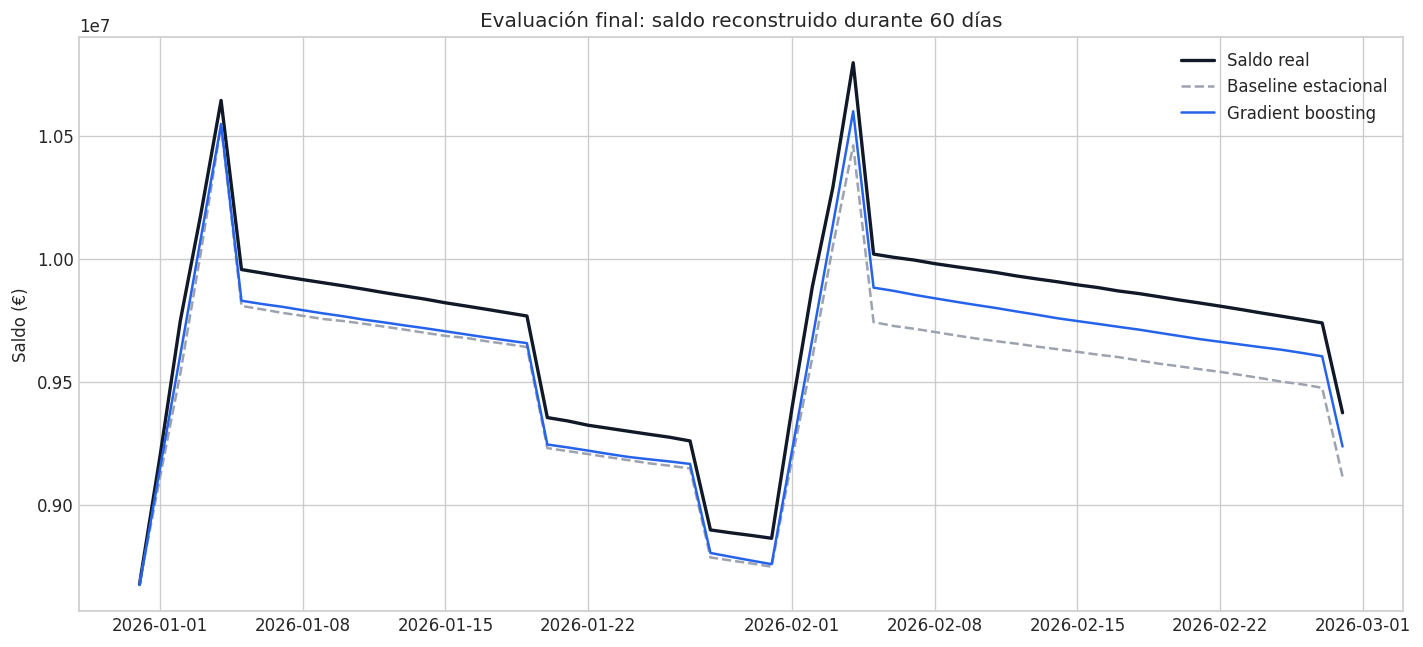

In [15]:
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(
    actual_test["Fecha"],
    actual_test["Saldo_Bancario"],
    label="Saldo real",
    color="#111827",
    linewidth=2,
)
ax.plot(
    test_forecasts["seasonal_naive"]["Fecha"],
    test_forecasts["seasonal_naive"]["Saldo_Previsto"],
    label="Baseline estacional",
    color="#9ca3af",
    linestyle="--",
)
ax.plot(
    test_forecasts["gradient_boosting"]["Fecha"],
    test_forecasts["gradient_boosting"]["Saldo_Previsto"],
    label="Gradient boosting",
    color="#2563eb",
)

ax.set_title("Evaluación final: saldo reconstruido durante 60 días")
ax.set_ylabel("Saldo (€)")
ax.legend()
plt.tight_layout()
plt.savefig("reports/figures/test_balance_comparison.png", dpi=150)
plt.show()

### Interpretación de la prueba

El WAPE mide el error agregado de los flujos diarios, mientras que el MAE del saldo mide la desviación media de la posición de liquidez reconstruida.

Un error del saldo puede acumularse aunque los errores diarios sean moderados. Por eso se presentan ambas métricas y no se resume el rendimiento en un único porcentaje.

## 7. Previsión futura y escenarios

Se entrena el método seleccionado con todo el histórico y se proyectan los 60 días posteriores al 28 de febrero de 2026.

Los escenarios no son intervalos probabilísticos:

- **Base:** previsión del modelo sin ajustes.
- **Adverso:** cobros un 10 % inferiores y pagos operativos un 5 % superiores.
- **Favorable:** cobros un 5 % superiores y pagos operativos un 2 % inferiores.

In [16]:
future_dates = pd.date_range(
    data["Fecha"].max() + pd.Timedelta(days=1),
    periods=HORIZON,
    freq="D",
)

if selected_method == "gradient_boosting":
    base_forecast = gradient_boosting_forecast(data, future_dates)
else:
    base_forecast = seasonal_naive_forecast(data, future_dates)

opening_future_balance = float(data["Saldo_Bancario"].iloc[-1])
scenario_assumptions = {
    "Base": (1.00, 1.00),
    "Adverso": (0.90, 1.05),
    "Favorable": (1.05, 0.98),
}

scenarios = pd.DataFrame({"Fecha": future_dates})

for scenario, (collections_factor, operating_factor) in scenario_assumptions.items():
    scenario_flow = (
        base_forecast["Cobros_Previstos"] * collections_factor
        - base_forecast["Pagos_Operativos_Previstos"] * operating_factor
        - base_forecast["Pagos_Programados"]
    )
    scenarios[f"Flujo_{scenario}"] = scenario_flow
    scenarios[f"Saldo_{scenario}"] = (
        opening_future_balance + scenario_flow.cumsum()
    )

scenarios.to_csv("reports/forecast_scenarios_60d.csv", index=False)
display(scenarios.head())

,Fecha,Flujo_Base,Saldo_Base,Flujo_Adverso,Saldo_Adverso,Flujo_Favorable,Saldo_Favorable
0,2026-03-01,"446,391.96","9,820,528.10","399,364.11","9,773,500.25","469,826.27","9,843,962.41"
1,2026-03-02,"429,856.77","10,250,384.88","384,392.48","10,157,892.74","452,506.30","10,296,468.70"
2,2026-03-03,"436,842.17","10,687,227.05","390,561.46","10,548,454.20","459,895.98","10,756,364.68"
3,2026-03-04,"480,494.64","11,167,721.69","429,962.69","10,978,416.89","505,677.86","11,262,042.55"
4,2026-03-05,"-745,007.08","10,422,714.61","-792,910.80","10,185,506.08","-721,135.37","10,540,907.18"


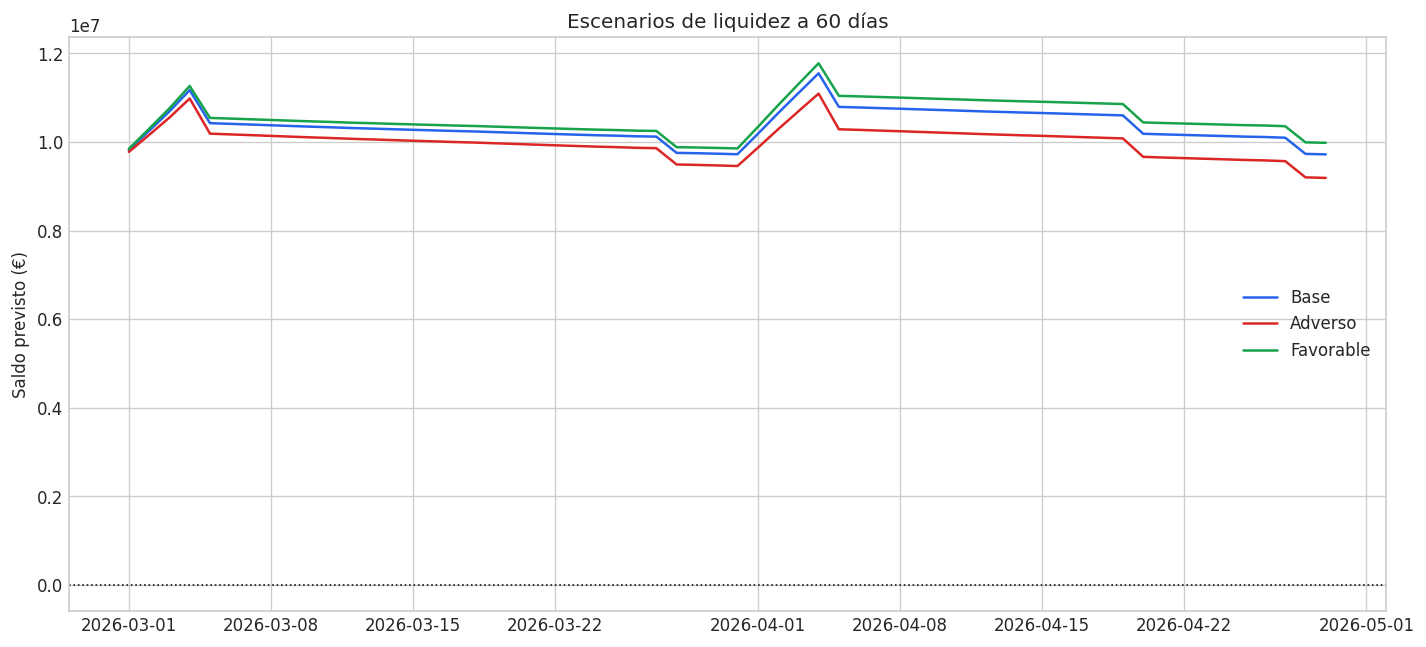

In [17]:
fig, ax = plt.subplots(figsize=(12, 5.5))
scenario_colors = {
    "Base": "#2563eb",
    "Adverso": "#dc2626",
    "Favorable": "#16a34a",
}

for scenario, color in scenario_colors.items():
    ax.plot(
        scenarios["Fecha"],
        scenarios[f"Saldo_{scenario}"],
        label=scenario,
        color=color,
    )

ax.axhline(0, color="#111827", linestyle=":", linewidth=1)
ax.set_title("Escenarios de liquidez a 60 días")
ax.set_ylabel("Saldo previsto (€)")
ax.legend()
plt.tight_layout()
plt.savefig("reports/figures/forecast_scenarios_60d.png", dpi=150)
plt.show()

In [18]:
scenario_summary = pd.DataFrame(
    {
        scenario: {
            "Saldo mínimo": scenarios[f"Saldo_{scenario}"].min(),
            "Saldo final": scenarios[f"Saldo_{scenario}"].iloc[-1],
            "Variación frente al saldo inicial": (
                scenarios[f"Saldo_{scenario}"].iloc[-1]
                - opening_future_balance
            ),
        }
        for scenario in scenario_assumptions
    }
).T

scenario_summary.round(2)

,Saldo mínimo,Saldo final,Variación frente al saldo inicial
Base,"9,718,307.56","9,718,307.56","344,171.42"
Adverso,"9,187,217.64","9,187,217.64","-186,918.50"
Favorable,"9,843,962.41","9,978,963.42","604,827.28"


## 8. Conclusiones y limitaciones

### Conclusiones del ejercicio

- Separar los flujos conocidos de los inciertos evita pedir al modelo que aprenda reglas ya disponibles en el calendario financiero.
- La validación temporal permite comparar modelos sin mezclar pasado y futuro.
- En este escenario sintético, gradient boosting supera al baseline en las ventanas de validación y en el periodo final.
- El saldo se reconstruye a partir de los flujos previstos, de modo que el resultado puede relacionarse con cobros, pagos y obligaciones concretas.
- Los escenarios sirven para analizar sensibilidad, no para asignar probabilidades.

### Limitaciones

- Todos los datos son sintéticos.
- Los pagos programados se consideran conocidos sin error.
- No se modelizan retrasos de clientes, límites de crédito, divisas ni cambios inesperados.
- El rendimiento sobre este escenario no garantiza resultados con información real.
- En producción serían necesarios controles de calidad, reentrenamiento y seguimiento del error por horizonte.